<a href="https://colab.research.google.com/github/aghyaraga-hub/Radyandra-Tugas-Pertemuan-4/blob/main/Decisisiom%20Three.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome       

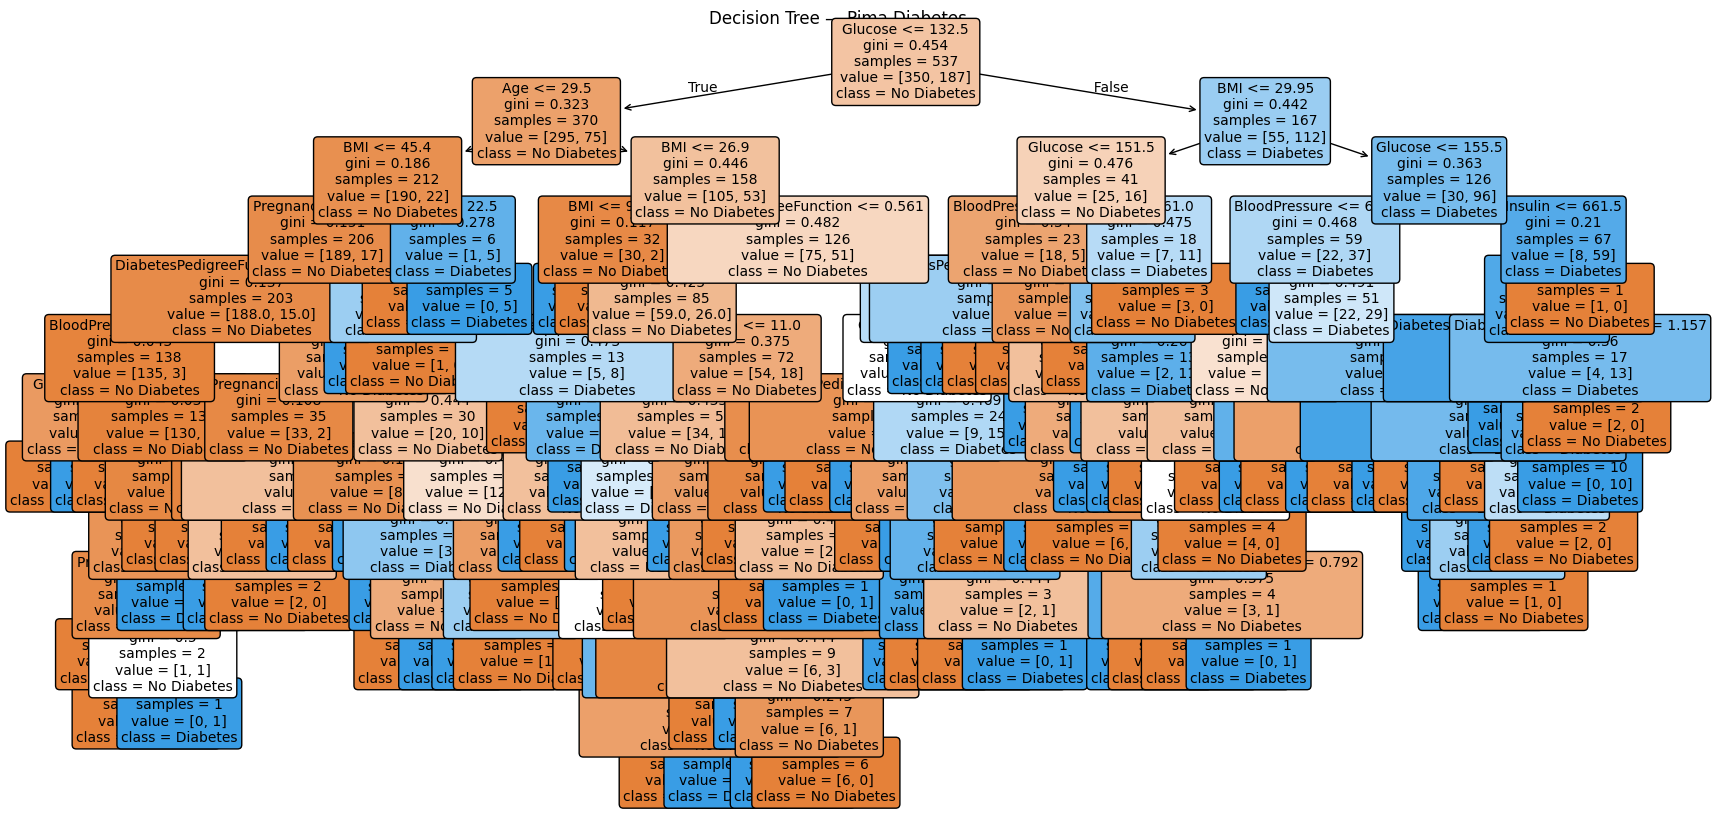

In [4]:
# 1. Import library yang dibutuhkan
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 2. Load dataset langsung dari URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = [
    'Pregnancies', 'Glucose', 'BloodPressure',
    'SkinThickness', 'Insulin', 'BMI',
    'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df = pd.read_csv(url, names=column_names)

print("Data shape:", df.shape)
print(df.head())

# 3. Cek apakah ada missing values (opsional)
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 5. Bagi data ke training & testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nJumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])

# 6. Buat model Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 7. Prediksi data test
y_pred = clf.predict(X_test)

# 8. Evaluasi model
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n=== Hasil Evaluasi ===")
print("Accuracy :", acc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# 9. Visualisasikan tree (opsional)
plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree — Pima Diabetes")
plt.show()